In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline


import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import argparse
import os
from pathlib import Path
import json
import re
import numpy as np
import importlib
from typing import Callable, Any
OUTPUT_DIR = "graficos"


In [2]:

ALGORITHMS = {}
ALGORITHMS['cryptography'] = {
    'ecdsa': {
        1: 'P-256',
        3: 'P-384',
        5: 'P-521'
    },
}

ALGORITHMS['liboqs'] =  {
    'mldsa': {
        1: 'ML-DSA-44',
        2: 'ML-DSA-44',
        3: 'ML-DSA-65',
        5: 'ML-DSA-87'
    },
    'dilithium': {
        1: 'Dilithium2',
        2: 'Dilithium2',
        3: 'Dilithium3',
        5: 'Dilithium5'
    },
    'sphincs-sha-s': {
        1: 'SPHINCS+-SHA2-128s-simple',
        3: 'SPHINCS+-SHA2-192s-simple',
        5: 'SPHINCS+-SHA2-256s-simple'
    },
    'sphincs-sha-f': {
        1: 'SPHINCS+-SHA2-128f-simple',
        3: 'SPHINCS+-SHA2-192f-simple',
        5: 'SPHINCS+-SHA2-256f-simple'
    },
    'sphincs-shake-s': {
        1: 'SPHINCS+-SHAKE-128s-simple',
        3: 'SPHINCS+-SHAKE-192s-simple',
        5: 'SPHINCS+-SHAKE-256s-simple'
    },
    'sphincs-shake-f': {
        1: 'SPHINCS+-SHAKE-128f-simple',
        3: 'SPHINCS+-SHAKE-192f-simple',
        5: 'SPHINCS+-SHAKE-256f-simple'
    },
    'falcon': {
        1: 'Falcon-512',
        5: 'Falcon-1024'
    },
    'falcon-padded': {
        1: 'Falcon-padded-512',
        5: 'Falcon-padded-1024'
    },
    'mayo': {
        1: 'MAYO-2',
        3: 'MAYO-3',
        5: 'MAYO-5'
    },
    'cross-rsdp-small': {
        1: 'cross-rsdp-128-small',
        3: 'cross-rsdp-192-small',
        5: 'cross-rsdp-256-small'
    },
    'cross-rsdpg-small': {
        1: 'cross-rsdpg-128-small',
        3: 'cross-rsdpg-192-small',
        5: 'cross-rsdpg-256-small'
    },
    'cross-rsdp-balanced': {
        1: 'cross-rsdp-128-balanced',
        3: 'cross-rsdp-192-balanced',
        5: 'cross-rsdp-256-balanced'
    },
    'cross-rsdpg-balanced': {
        1: 'cross-rsdpg-128-balanced',
        3: 'cross-rsdpg-192-balanced',
        5: 'cross-rsdpg-256-balanced'
    },
    'cross-rsdp-fast': {
        1: 'cross-rsdp-128-fast',
        3: 'cross-rsdp-192-fast',
        5: 'cross-rsdp-256-fast'
    },
    'cross-rsdpg-fast': {
        1: 'cross-rsdpg-128-fast',
        3: 'cross-rsdpg-192-fast',
        5: 'cross-rsdpg-256-fast'
    }
}


In [3]:
def ensure_output_dir(output_dir):
    """
    Checks if OUTPUT_DIR exists, and creates it if not.
    """
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
        print(f"Created directory: {output_dir}")
    else:
        print(f"Directory already exists: {output_dir}")

ensure_output_dir(OUTPUT_DIR)

Directory already exists: graficos


In [20]:
def find_csv_recursive(root_dir, filename):
    """
    Recursively search for a file named `filename` in `root_dir`.
    Returns the full path if found, else None.
    """
    for dirpath, _, files in os.walk(root_dir):
        if filename in files:
            return os.path.join(dirpath, filename)
    return None

def load_results(input_dir,  index_col="variant"):
    """
    Loads CSV data from each subdirectory in input_dir.
    Returns a dictionary:
    {
        'subdir_name': {
            'time-evaluation-tmean-std': pd.DataFrame,
            'blocksim-mean-std': pd.DataFrame
        },
        ...
    }
    """
    results = {}
    for subdir in os.listdir(input_dir):
        subdir_path = os.path.join(input_dir, subdir)
        if os.path.isdir(subdir_path):
            data = {}
            for key in ['time-evaluation-mean-std', 'blocksim-mean-std', 'blocksim-mean-std', 'blocksim-model-2-mean-std', 'blocksim-model-1-mean-std']:
                csv_path = find_csv_recursive(subdir_path, f"{key}.csv")
                if csv_path:
                    data[key] = pd.read_csv(csv_path, index_col=index_col)
                else:
                    data[key] = None  # or pd.DataFrame() if preferred
            results[subdir] = data
    return results

results = load_results("../Inputs/CBlockchain/desktop-mid-end")
print(results)  # Print the keys to verify loading

{'simulator': {'time-evaluation-mean-std': None, 'blocksim-mean-std': None, 'blocksim-model-2-mean-std':                             mean_verify  std_verify
variant                                            
Dilithium2                     3.480275    0.086138
Dilithium3                     5.537100    0.139257
Dilithium5                     8.523388    0.216981
Falcon-1024                   11.691041    0.290977
Falcon-512                     6.286233    0.157578
Falcon-padded-1024            11.600881    0.288666
Falcon-padded-512              6.189407    0.157392
MAYO-2                         3.149348    0.077859
MAYO-3                        11.010562    0.274842
MAYO-5                        22.016242    0.506375
ML-DSA-44                      3.491653    0.086498
ML-DSA-65                      5.554030    0.141903
ML-DSA-87                      8.463729    0.205135
P-256                         10.267931    0.254573
P-384                         59.618875    1.491909
P-521      

In [21]:
def get_variants_by_level(df, variant_dict):
    csv_variants = set(df.index.to_list())
    print("CSV Variants:", csv_variants)
    variants_by_level = {}

    for algorithm, levels in variant_dict.items():
        for level, variant in levels.items():
            if variant in csv_variants:
                variants_by_level.setdefault(level, []).append({
                    "algorithm": algorithm,
                    "variant": variant
                })
             
    return dict(sorted(variants_by_level.items()))

def filter_algorithms(algorithms: dict, selected_algorithms: list = None, selected_levels: list = None) -> dict:
    selected_algorithms = selected_algorithms or []
    selected_levels = selected_levels or []

    filtered = {}

    for module, algos in algorithms.items():
        for algorithm, variants in algos.items():
            if selected_algorithms and algorithm not in selected_algorithms:
                continue

            selected_variants = {
                level: name for level, name in variants.items()
                if not selected_levels or level in selected_levels
            }

            if selected_variants:
                filtered.setdefault(module, {})[algorithm] = selected_variants

    return filtered


In [22]:
def algorithm_to_label(algorithm):
    mapping = {
        'ecdsa': 'ECDSA',
        'mldsa': 'ML-DSA',
        'dilithium': 'Dilithium',
        'sphincs-sha-s': 'SPHINCS+-SHA-s',
        'sphincs-sha-f': 'SPHINCS+-SHA-f',
        'sphincs-shake-s': 'SPHINCS+-SHAKE-s',
        'sphincs-shake-f': 'SPHINCS+-SHAKE-f',
        'falcon': 'Falcon',
        'falcon-padded': 'Falcon-padded',
        'mayo': 'MAYO',
        'cross-rsdp-small': 'CROSS-RSDP-small',
        'cross-rsdpg-small': 'CROSS-RSDPG-small',
        'cross-rsdp-balanced': 'CROSS-RSDP-balanced',
        'cross-rsdpg-balanced': 'CROSS-RSDPG-balanced',
        'cross-rsdp-fast': 'CROSS-RSDP-fast',
        'cross-rsdpg-fast': 'CROSS-RSDPG-fast'
    }
    return mapping.get(algorithm, algorithm)

All algorithms loaded: ['cryptography', 'liboqs']
Filtered algorithms: {'cryptography': {'ecdsa': {1: 'P-256', 3: 'P-384', 5: 'P-521'}}, 'liboqs': {'mldsa': {1: 'ML-DSA-44', 3: 'ML-DSA-65', 5: 'ML-DSA-87'}, 'falcon': {1: 'Falcon-512', 5: 'Falcon-1024'}, 'mayo': {1: 'MAYO-2', 3: 'MAYO-3', 5: 'MAYO-5'}}}
Combined mechanisms: {'ecdsa': {1: 'P-256', 3: 'P-384', 5: 'P-521'}, 'mldsa': {1: 'ML-DSA-44', 3: 'ML-DSA-65', 5: 'ML-DSA-87'}, 'falcon': {1: 'Falcon-512', 5: 'Falcon-1024'}, 'mayo': {1: 'MAYO-2', 3: 'MAYO-3', 5: 'MAYO-5'}}
CSV Variants: {'ML-DSA-87', 'P-384', 'Falcon-padded-1024', 'MAYO-3', 'ML-DSA-65', 'cross-rsdp-192-balanced', 'SPHINCS+-SHAKE-192f-simple', 'SPHINCS+-SHA2-256f-simple', 'SPHINCS+-SHA2-192s-simple', 'cross-rsdp-128-small', 'cross-rsdpg-192-small', 'Falcon-1024', 'SPHINCS+-SHA2-256s-simple', 'SPHINCS+-SHAKE-128s-simple', 'SPHINCS+-SHAKE-128f-simple', 'Falcon-512', 'cross-rsdpg-256-balanced', 'cross-rsdpg-192-balanced', 'SPHINCS+-SHA2-192f-simple', 'cross-rsdp-256-fast', 

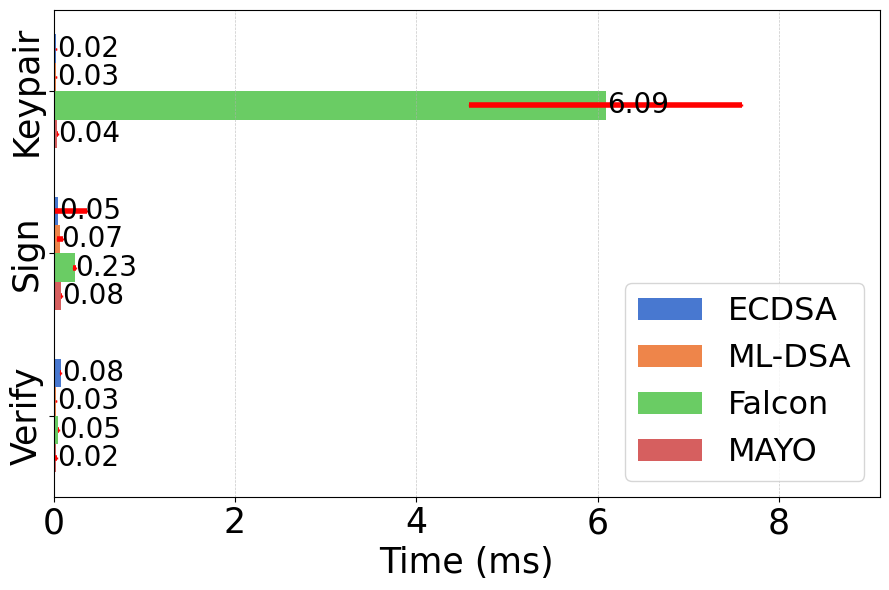

Processing benchmark, level 3
Adding missing algorithm: falcon
Final algorithms: ['ecdsa', 'mldsa', 'falcon', 'mayo']
[('mean_verify', 'std_verify', 'Verify'), ('mean_sign', 'std_sign', 'Sign'), ('mean_keypair', 'std_keypair', 'Keypair')]
[('mean_verify', 'std_verify', 'Verify'), ('mean_sign', 'std_sign', 'Sign'), ('mean_keypair', 'std_keypair', 'Keypair')]
[('mean_verify', 'std_verify', 'Verify'), ('mean_sign', 'std_sign', 'Sign'), ('mean_keypair', 'std_keypair', 'Keypair')]
[('mean_verify', 'std_verify', 'Verify'), ('mean_sign', 'std_sign', 'Sign'), ('mean_keypair', 'std_keypair', 'Keypair')]
[('mean_verify', 'std_verify', 'Verify'), ('mean_sign', 'std_sign', 'Sign'), ('mean_keypair', 'std_keypair', 'Keypair')]
Saved: graficos/bench_benchmark_level-3.pdf


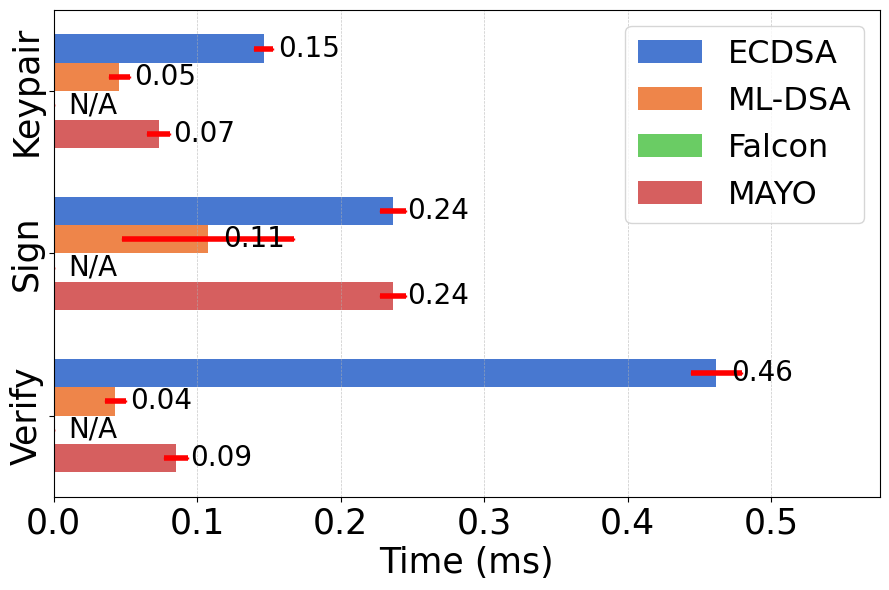

Processing benchmark, level 5
Final algorithms: ['ecdsa', 'mldsa', 'falcon', 'mayo']
[('mean_verify', 'std_verify', 'Verify'), ('mean_sign', 'std_sign', 'Sign'), ('mean_keypair', 'std_keypair', 'Keypair')]
[('mean_verify', 'std_verify', 'Verify'), ('mean_sign', 'std_sign', 'Sign'), ('mean_keypair', 'std_keypair', 'Keypair')]
[('mean_verify', 'std_verify', 'Verify'), ('mean_sign', 'std_sign', 'Sign'), ('mean_keypair', 'std_keypair', 'Keypair')]
[('mean_verify', 'std_verify', 'Verify'), ('mean_sign', 'std_sign', 'Sign'), ('mean_keypair', 'std_keypair', 'Keypair')]
[('mean_verify', 'std_verify', 'Verify'), ('mean_sign', 'std_sign', 'Sign'), ('mean_keypair', 'std_keypair', 'Keypair')]
Saved: graficos/bench_benchmark_level-5.pdf


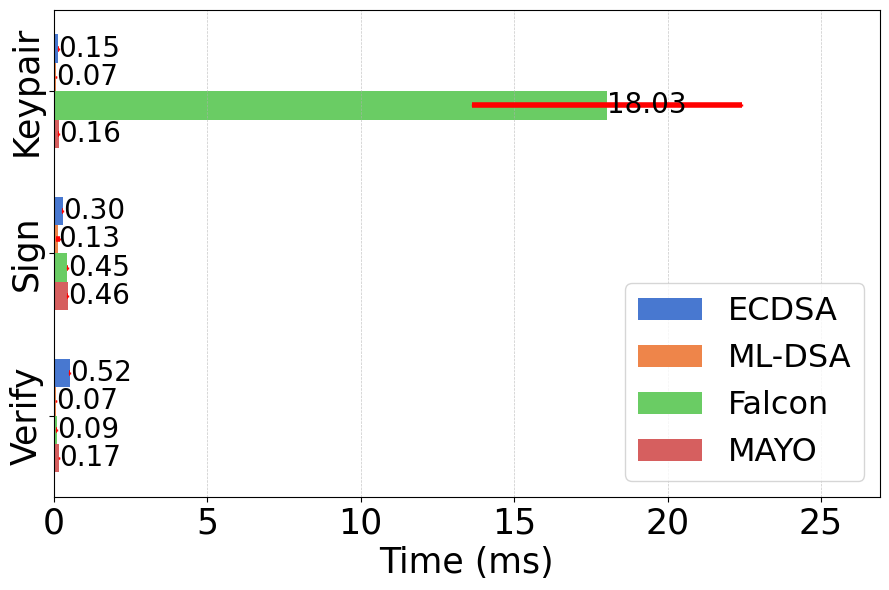

In [23]:
def plot_horizontal_multiple_inverted(
    dfs,                # lista de DataFrames
    columns,
    graphics_directory,
    values_offset,
    error_offset,
    levels=None,        # levels (optional)
    xscale="linear",
    xlabel=None,
    xlim=None,
    xticks=None,
    yticklabels="operation",  # Operations on Y-axis
    figsize=None,
    width=0.7,
    titles=None,        # titles (optional)
    ylabel=None,
    show_graph=False,
    show_values=True,
    show_errors=True,
    show_legend=True,
    save_formats=("pdf", "png"),
    file_name="multiples",
    pallet_start=0,
    legend_location="best"
):
    """
    Plots multiple horizontal graphs (one per DataFrame).
    Bars represent operations grouped by algorithm.
    """
    n_plots = len(dfs)
    fig, axes = plt.subplots(1, 1, figsize=figsize, squeeze=False)
    axes = axes.flatten()
    fontsize = 25
    
    for idx, df in enumerate(dfs):
        # Get unique algorithms
        algorithms = df['algorithm'].unique()
        n_algorithms = len(algorithms)
        n_operations = len(columns)  # keypair, sign, verify
        
        width_bar = width / n_algorithms
        y = np.arange(n_operations)  # y represents operations
        ax = axes[idx]
        palette = sns.color_palette("muted", n_colors=len(algorithms) + pallet_start)
        
        max_x_value = 0
        
        # Para cada algoritmo
        for algo_idx, algorithm in enumerate(algorithms):
            color = palette[algo_idx + pallet_start]
            
            # Encontrar os dados para este algoritmo
            algo_data = df[df['algorithm'] == algorithm]
            if len(algo_data) == 0:
                continue
                
            # Collect values per operation
            values = []
            errors = []
            operation_labels = []
            print(columns)
             
            for i, (val_col, err_col, label) in enumerate(columns):
                if len(algo_data) > 0:
                    val = algo_data[val_col].iloc[0]
                    err = algo_data[err_col].iloc[0] if err_col in algo_data else 0
                    values.append(val)
                    errors.append(err)
                    operation_labels.append(label)
                    
                    if val + err > max_x_value:
                        max_x_value = val + err
            
            bars = ax.barh(
                y + ((n_algorithms - 1 - algo_idx) - (n_algorithms - 1) / 2) * width_bar,
                values,
                height=width_bar,
                xerr=errors if show_errors else None,
                label=algorithm_to_label(algorithm),  # Use algorithm name as label
                color=color,
                error_kw={"capsize": 1, "ecolor": "red", "elinewidth": 4}
            )

            if show_values:
                for bar, value in zip(bars, values):
                    if value == 0:
                        ax.text(
                            values_offset,
                            bar.get_y() + bar.get_height() / 2,
                            f"N/A",
                            va="center",
                            ha="left",
                            fontsize=fontsize-5,
                            color="black",
                        )
                    else:
                        ax.text(
                            value + values_offset,
                            bar.get_y() + bar.get_height() / 2,
                            f"{value:.2f}",
                            va="center",
                            ha="left",
                            fontsize=fontsize-5,
                            color="black",
                        )

        # Set Y-axis labels to operation names
        ax.set_yticks(y)
        operation_names = [col[2] for col in columns]  # Pega os nomes: "Keypair", "Sign", "Verify"
        ax.set_yticklabels(operation_names, rotation=90, va="center", fontsize=fontsize)

        if ylabel:
            ax.set_ylabel(ylabel, fontsize=fontsize)
        if xlabel:
            ax.set_xlabel(xlabel, fontsize=fontsize)
        if titles and idx < len(titles):
            ax.set_title(titles[idx], fontsize=fontsize)

        ax.set_xscale(xscale)
        if xscale == "log" and xticks is not None:
            ax.set_xticks(xticks)
        if xscale == "linear":
            if xlim is not None and xlim[1] is not None:
                ax.set_xlim(*xlim)
            else:
                # If it doesn't receive a xlim, add 15% extra space on the right to fit the text.
                ax.set_xlim(0, max_x_value * 1.20)
        
        if len(y) > 0:
            ax.set_ylim(y[0] - 0.5, y[-1] + 0.5)
        
        ax.tick_params(axis="y", labelsize=fontsize)
        ax.tick_params(axis="x", labelsize=fontsize)
        if show_legend:
            ax.legend(loc=legend_location, fontsize=fontsize-2)
        ax.grid(True, axis="x", linestyle="--", linewidth=0.5, alpha=0.7)

    plt.tight_layout()
    
    for ext in save_formats:
        file = f"{graphics_directory}/{file_name}.{ext}"
        plt.savefig(file, format=ext, bbox_inches='tight')
        print(f"Saved: {file}")

    if show_graph:
        plt.show()
    plt.close()


columns = [
    ("mean_verify", "std_verify", "Verify"),
    ("mean_sign", "std_sign", "Sign"),
    ("mean_keypair", "std_keypair", "Keypair")
    ]

sign = """ecdsa
    mldsa
    falcon
   mayo 
    """
sign_list = [s.strip() for s in sign.split()]
print("All algorithms loaded:", list(all_algorithms.keys()))
filtered_algorithms = filter_algorithms(all_algorithms, sign_list, levels)
print("Filtered algorithms:", filtered_algorithms)
combined_mechanisms = {}
for algorithm in filtered_algorithms.values():
    combined_mechanisms.update(algorithm)

print("Combined mechanisms:", combined_mechanisms)

# Using the inverted function:
for m in ["benchmark"]:
    df_ethereum = results[m]["time-evaluation-mean-std"]
    variants_by_level = get_variants_by_level(df_ethereum, combined_mechanisms)
    
    for level, variants in variants_by_level.items():
        print(f"Processing {m}, level {level}")
        
        variant_to_algorithm = {v["variant"]: v["algorithm"] for v in variants}
        variant_names = [v["variant"] for v in variants]
        
        df_ethereum_subset = df_ethereum.loc[variant_names].copy()
        df_ethereum_subset["algorithm"] = df_ethereum_subset.index.map(variant_to_algorithm)
        
        # Adicionar algoritmos faltantes
        for s in sign_list:
            if s not in df_ethereum_subset["algorithm"].values:
                print(f"Adding missing algorithm: {s}")
                new_row = {}
                for col in df_ethereum_subset.columns:
                    if col != "algorithm":
                        new_row[col] = 0.0
                    else:
                        new_row[col] = s
                new_row["variant"] = f"N/A-{s}"
                new_row_df = pd.DataFrame([new_row]).set_index("variant")
                df_ethereum_subset = pd.concat([df_ethereum_subset, new_row_df])
        
        # Ordenar por algoritmo
        df_ethereum_subset["algorithm"] = pd.Categorical(
            df_ethereum_subset["algorithm"], 
            categories=sign_list, 
            ordered=True
        )
        df_ethereum_subset = df_ethereum_subset.sort_values("algorithm")
        
        print(f"Final algorithms: {df_ethereum_subset['algorithm'].tolist()}")
        print(columns)
         
        
        xlims={1:.99, 3:1.45, 5:2.99} 
        # Use inverted function
        plot_horizontal_multiple_inverted(
            dfs=[df_ethereum_subset],
            columns=columns,
            graphics_directory=OUTPUT_DIR,
            values_offset=0.01,
            error_offset=0,
            xscale="linear",
            xlabel="Time (ms)",
            # xlim=(0, xlims[level]),
            yticklabels="operation",
            figsize=(9, 6),
            width=0.7,
            # ylabel="Operations",
            show_graph=True,
            show_values=True,
            show_errors=True,
            show_legend=True,
            save_formats=["pdf"],
            file_name=f"bench_{m}_level-{level}"
        )

All algorithms loaded: ['cryptography', 'liboqs']
Filtered algorithms: {'cryptography': {'ecdsa': {1: 'P-256', 3: 'P-384', 5: 'P-521'}}, 'liboqs': {'mldsa': {1: 'ML-DSA-44', 3: 'ML-DSA-65', 5: 'ML-DSA-87'}, 'falcon': {1: 'Falcon-512', 5: 'Falcon-1024'}, 'mayo': {1: 'MAYO-2', 3: 'MAYO-3', 5: 'MAYO-5'}}}
Combined mechanisms: {'ecdsa': {1: 'P-256', 3: 'P-384', 5: 'P-521'}, 'mldsa': {1: 'ML-DSA-44', 3: 'ML-DSA-65', 5: 'ML-DSA-87'}, 'falcon': {1: 'Falcon-512', 5: 'Falcon-1024'}, 'mayo': {1: 'MAYO-2', 3: 'MAYO-3', 5: 'MAYO-5'}}
Processing results for simulator: dict_keys(['time-evaluation-mean-std', 'blocksim-mean-std', 'blocksim-model-2-mean-std', 'blocksim-model-1-mean-std'])
Processing results for benchmark: dict_keys(['time-evaluation-mean-std', 'blocksim-mean-std', 'blocksim-model-2-mean-std', 'blocksim-model-1-mean-std'])
All algorithms loaded: ['cryptography', 'liboqs']
CSV Variants: {'ML-DSA-87', 'MAYO-3', 'Falcon-padded-1024', 'P-384', 'ML-DSA-65', 'cross-rsdp-192-balanced', 'SPHINC

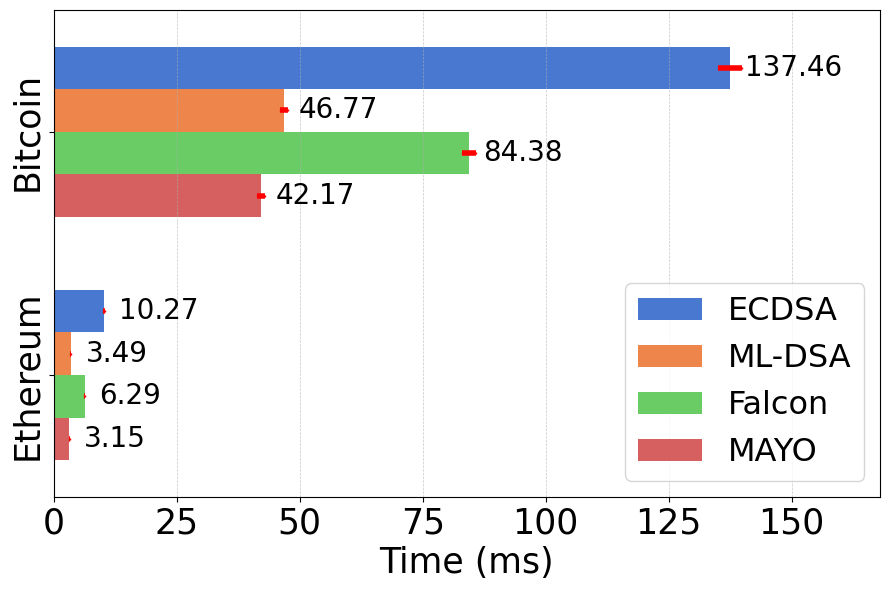

	Processing level 3 with variants: [{'algorithm': 'ecdsa', 'variant': 'P-384'}, {'algorithm': 'mldsa', 'variant': 'ML-DSA-65'}, {'algorithm': 'mayo', 'variant': 'MAYO-3'}]
Variant to Algorithm mapping: {'P-384': 'ecdsa', 'ML-DSA-65': 'mldsa', 'MAYO-3': 'mayo'}

DataFrame with algorithm column:
             mean_verify  std_verify  Bitcoin_mean_verify  Bitcoin_std_verify  \
variant                                                                        
P-384         59.618875    1.491909           798.563948           14.103133   
ML-DSA-65      5.554030    0.141903            74.476226            1.288577   
N/A-falcon     0.000000    0.000000             0.000000            0.000000   
MAYO-3        11.010562    0.274842           147.528018            2.672960   

           algorithm          algorithm2  
variant                                   
P-384          ecdsa      ecdsa\n(P-384)  
ML-DSA-65      mldsa  mldsa\n(ML-DSA-65)  
N/A-falcon    falcon              falcon  
MAYO-3  

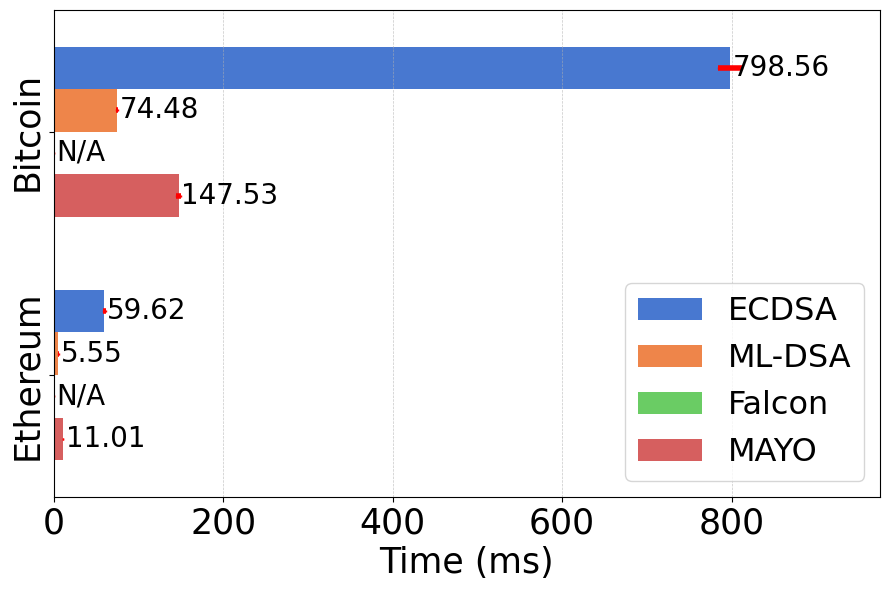

	Processing level 5 with variants: [{'algorithm': 'ecdsa', 'variant': 'P-521'}, {'algorithm': 'mldsa', 'variant': 'ML-DSA-87'}, {'algorithm': 'falcon', 'variant': 'Falcon-1024'}, {'algorithm': 'mayo', 'variant': 'MAYO-5'}]
Variant to Algorithm mapping: {'P-521': 'ecdsa', 'ML-DSA-87': 'mldsa', 'Falcon-1024': 'falcon', 'MAYO-5': 'mayo'}

DataFrame with algorithm column:
              mean_verify  std_verify  Bitcoin_mean_verify  Bitcoin_std_verify  \
variant                                                                         
P-521          67.038836    1.695063           898.057766           15.824814   
ML-DSA-87       8.463729    0.205135           113.512779            1.939966   
Falcon-1024    11.691041    0.290977           156.763680            2.846081   
MAYO-5         22.016242    0.506375           294.318563            5.218720   

            algorithm             algorithm2  
variant                                       
P-521           ecdsa         ecdsa\n(P-521)  


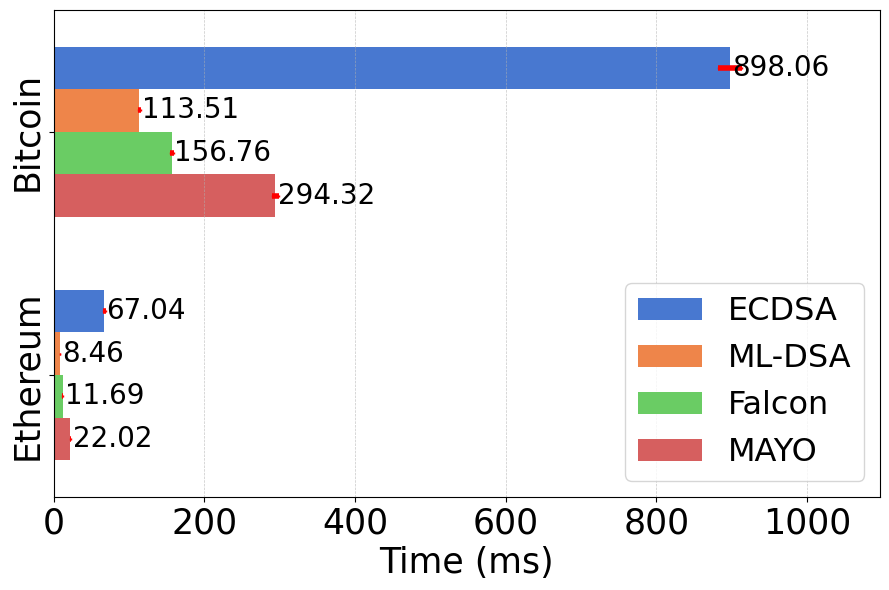

In [25]:
all_algorithms = ALGORITHMS
levels = [1, 3, 5]

sign = """ecdsa
    mldsa
    falcon
    mayo
    """
sign_list = [s.strip() for s in sign.split()]

print("All algorithms loaded:", list(all_algorithms.keys()))
filtered_algorithms = filter_algorithms(all_algorithms, sign_list, levels)
print("Filtered algorithms:", filtered_algorithms)
combined_mechanisms = {}
for algorithm in filtered_algorithms.values():
    combined_mechanisms.update(algorithm)

print("Combined mechanisms:", combined_mechanisms)

columns = [
        ("mean_verify", "std_verify", "Ethereum"),
        ("Bitcoin_mean_verify", "Bitcoin_std_verify", "Bitcoin"),
    ]
for r in results.keys():
    print(f"Processing results for {r}: {results[r].keys()}")  


print("All algorithms loaded:", list(all_algorithms.keys()))
# for m in ["a9", "airm1", "airm2", "laptop-windows-wsl",  "xps-9320", "deeppurple"]:

for m in ["simulator"]:
    df_ethereum = results[m]["blocksim-model-2-mean-std"]
    df_bitcoin = results[m]["blocksim-model-1-mean-std"]
    variants_by_level = get_variants_by_level(df_ethereum, combined_mechanisms)
    print("Variants by level:", variants_by_level)
    dfs = []
    
    for level, variants in variants_by_level.items():
        print(f"\tProcessing level {level} with variants: {variants}")
        variant_to_algorithm = {v["variant"]: v["algorithm"] for v in variants}
        print("Variant to Algorithm mapping:", variant_to_algorithm)
        variant_names = [v["variant"] for v in variants]
        
        df_ethereum_subset = df_ethereum.loc[variant_names].copy()  # Explicit copy to avoid SettingWithCopyWarning
        df_bitcoin_subset = df_bitcoin.loc[variant_names].copy()

        # Map algorithm names
        df_ethereum_subset["algorithm"] = df_ethereum_subset.index.map(variant_to_algorithm)
        
        # Add missing algorithms BEFORE creating algorithm2
        for s in sign_list:
            if s not in df_ethereum_subset["algorithm"].values:
                new_row = {col: 0.000000000000 for col in df_ethereum_subset.columns}
                new_row["algorithm"] = s
                new_row["variant"] = f"N/A-{s}"
                new_row_df = pd.DataFrame([new_row]).set_index("variant")
                df_ethereum_subset = pd.concat([df_ethereum_subset, new_row_df])
         
        # Now create algorithm2 after all rows exist
        df_ethereum_subset["algorithm2"] = df_ethereum_subset.apply(
            lambda x: f"{x['algorithm']}\n({x.name})" if "N/A" not in str(x.name) 
                     else x['algorithm'],
            axis=1
        )
        
        df_ethereum["Bitcoin_mean_verify"] = df_bitcoin["mean_verify"]
        df_ethereum["Bitcoin_std_verify"] = df_bitcoin["std_verify"]
         

        # Sort and categorize
        df_ethereum_subset["algorithm"] = pd.Categorical(
            df_ethereum_subset["algorithm"], 
            categories=sign_list, 
            ordered=True
        )
        df_ethereum_subset = df_ethereum_subset.sort_values("algorithm")
        
        print("\nDataFrame with algorithm column:\n", df_ethereum_subset)
        #dfs.append(df_subset)

        xscale = "linear"
        xlabel = "Time (ms)"
        
        xticks = None
        # yticklabels = "variant" if "variant" in df.columns else df.index.name
        yticklabels = "algorithm"  # if "variant" in df.columns else df.index.name

        width = 0.7
         
        ylabel = None
        save_formats = ["pdf"]
        print(df_ethereum_subset)
         
        #log_xticks=np.logspace(-3, 4, num=8, base=10) 
        #log_xlim=(1e-3, 1e3) 
        xlims={1:160, 3:1499, 5:1799}
        plot_horizontal_multiple_inverted(
            dfs=[df_ethereum_subset],
            columns=columns,
            graphics_directory=OUTPUT_DIR,
            values_offset=3,
            error_offset=0,
            levels=levels,
            figsize=(9, 6),
            # levels=levels,
            xscale=xscale,
            xlabel=xlabel,
            # xlim=(0, xlims[level]),
            yticklabels=yticklabels,
            width=width,
            titles=None,
            ylabel=ylabel,
            show_graph=True,
            show_values=True,
            show_errors=True,
            show_legend=True,
             
            save_formats=save_formats,
            file_name=f"sim_{m}_level-{level}",
            pallet_start=0,
            legend_location="lower right" 
                        )

         